In [1]:
!pip install --quiet \
    "openai>=1.66.0" \
    "requests>=2.31.0" \
    "pandas>=2.0.0" \
    "numpy>=1.26.0" \
    "scikit-learn>=1.4.0" \
    "pyarrow>=14.0.0" \
    "python-dotenv>=1.0.0"

import openai
print(f"openai version: {openai.__version__}")
assert tuple(int(x) for x in openai.__version__.split(".")[:2]) >= (1, 66), \
    f"openai >= 1.66.0 required, got {openai.__version__}. Run: !pip install --upgrade openai"
print("Dependency check passed.")

openai version: 2.32.0
Dependency check passed.


In [2]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = "test"
os.environ["OMDB_API_KEY"]   = "test"
os.environ["TMDB_API_KEY"]   = "test"

In [3]:
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
print("OpenAI client ready:", type(client).__name__)

OpenAI client ready: OpenAI


In [4]:
# Clone PicTropes repo
import subprocess
from pathlib import Path

result = subprocess.run(
    ["git", "clone", "--depth=1", "https://github.com/rhgarcia/tropes_open_data.git"],
    capture_output=True, text=True
)
print(result.stdout or "(already cloned)")
print(result.stderr)

repo_root = Path("tropes_open_data")
json_files = sorted(repo_root.rglob("*.json"))
for p in json_files:
    print(f"{p}  ({p.stat().st_size / 1024:.0f} KB)")

TROPES_JSON_PATH = "/content/tropes_open_data/data/all_films_and_their_tropes.json"

(already cloned)
Cloning into 'tropes_open_data'...

tropes_open_data/data/all_films_and_their_tropes.json  (6177 KB)


In [5]:
# Load and clean PicTropes
import json
import re
import pandas as pd
from collections import Counter, defaultdict
from typing import List, Dict, Tuple

with open(TROPES_JSON_PATH, "r", encoding="utf-8") as f:
    pictropes_raw = json.load(f)

print(f"Raw entries: {len(pictropes_raw)}")

def split_title_year(film_str: str) -> Tuple[str, int | None]:
    m = re.match(r"^(.*?)\s*\((\d{4})\)\s*$", film_str.strip())
    if m:
        return m.group(1).strip(), int(m.group(2))
    return film_str.strip(), None

rows = []
for film_key, tropes in pictropes_raw.items():
    if len(tropes) == 0:
        continue
    clean_title, year = split_title_year(film_key)
    rows.append({
        "film":       film_key,
        "title":      clean_title,
        "year":       year,
        "tropes":     tropes,
        "trope_set":  set(tropes),
        "num_tropes": len(tropes),
    })

films_df = pd.DataFrame(rows).set_index("film")
print(f"Films after filtering: {len(films_df)}")

all_tropes = [t for lst in films_df["tropes"] for t in lst]
trope_counts = Counter(all_tropes)
print(f"Unique tropes: {len(trope_counts)}")
print("Top 10:", [t for t, _ in trope_counts.most_common(10)])

Raw entries: 5925
Films after filtering: 5925
Unique tropes: 18270
Top 10: ['ShoutOut', 'ChekhovsGun', 'OhCrap', 'DeadpanSnarker', 'Jerkass', 'Foreshadowing', 'LargeHam', 'BittersweetEnding', 'TitleDrop', 'BigBad']


In [6]:
import difflib
import re
from collections import defaultdict

def camel_to_words(s: str) -> str:
    """
    Insert space before a capital that follows a lowercase or before a capital followed by a lowercase (handles acronyms)
    Handles consecutive caps (e.g. 'TVTropes' → 'TV Tropes') correctly.
    """
    s = re.sub(r'([a-z])([A-Z])', r'\1 \2', s)
    s = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', s)
    return s

def normalise(text: str) -> str:
    text = camel_to_words(text)
    text = re.sub(r'\(.*?\)', '', text)            # strip (Year) or (disambiguation)
    text = re.sub(r"[^a-z0-9 ]", "", text.lower()) # keep only alphanumeric + space
    return " ".join(text.split())


title_index_norm: dict[str, list[str]] = defaultdict(list)
for film_key in films_df.index:
    norm = normalise(film_key)
    title_index_norm[norm].append(film_key)

year_title_index: dict[tuple, str] = {}
for film_key, row in films_df.iterrows():
    norm = normalise(film_key)
    year = str(row["year"]) if row["year"] else ""
    year_title_index[(norm, year)] = film_key

ALL_NORMALISED = list(title_index_norm.keys())

def find_film_key(title: str, year: int | None = None, cutoff: float = 0.85) -> str | None:
    """
    Find the best-matching PicTropes film key for a given title.

    Strategy (tries each in order, returns on first match):
    1. Exact match on normalised title.
    2. Year-aware exact match.
    3. difflib fuzzy match on normalised title (configurable similarity cutoff).

    Args:
        title:   Movie title string (human-readable, CamelCase, or with year).
        year:    Release year if known.
        cutoff:  Fuzzy-match similarity threshold (0–1). Lower = more permissive.

    Returns:
        Matching film key string, or None if no match found.
    """
    norm_query = normalise(title)
    year_str   = str(year) if year else ""

    if norm_query in title_index_norm:
        candidates = title_index_norm[norm_query]
        if len(candidates) == 1:
            return candidates[0]
        if year_str:
            for key in candidates:
                if year_str in key:
                    return key
        return candidates[0]

    if year_str and (norm_query, year_str) in year_title_index:
        return year_title_index[(norm_query, year_str)]

    close = difflib.get_close_matches(norm_query, ALL_NORMALISED, n=3, cutoff=cutoff)
    if close:
        if year_str:
            for match in close:
                for key in title_index_norm[match]:
                    if year_str in key:
                        return key
        return title_index_norm[close[0]][0]

    return None

films_df_to_save = films_df.copy()
films_df_to_save["trope_set"] = films_df_to_save["trope_set"].apply(list)
films_df_to_save.reset_index().to_parquet("films_tropes.parquet", index=False)
print("Saved films_tropes.parquet")

def load_films_df(path: str = "films_tropes.parquet") -> pd.DataFrame:
    """Reload and restore trope_set as a Python set."""
    df = pd.read_parquet(path).set_index("film")
    df["trope_set"] = df["trope_set"].apply(set)
    return df

Saved films_tropes.parquet


In [7]:
# Jaccard similarity functions
def jaccard_similarity(film_a: str, film_b: str, df: pd.DataFrame = films_df) -> float:
    """
    Compute Jaccard similarity over trope sets.
    Returns 0.0 if either film is missing or union is empty.
    """
    if film_a not in df.index or film_b not in df.index:
        return 0.0
    set_a = df.loc[film_a, "trope_set"]
    set_b = df.loc[film_b, "trope_set"]
    union = len(set_a | set_b)
    return len(set_a & set_b) / union if union > 0 else 0.0


def top_k_similar(
    film: str,
    k: int = 10,
    df: pd.DataFrame = films_df,
    min_shared: int = 1
) -> List[Dict]:
    """
    Return top-k most trope-similar films to `film`.

    Each result dict has:
      film (str), similarity (float), shared_tropes (int),
      shared_trope_names (List[str])
    """
    if film not in df.index:
        return []
    target_set = df.loc[film, "trope_set"]
    results = []
    for other_film in df.index:
        if other_film == film:
            continue
        other_set = df.loc[other_film, "trope_set"]
        shared = target_set & other_set
        n = len(shared)
        if n < min_shared:
            continue
        union = len(target_set | other_set)
        results.append({
            "film":              other_film,
            "similarity":        round(n / union, 4),
            "shared_tropes":     n,
            "shared_trope_names": sorted(shared)[:20],
        })
    results.sort(key=lambda x: x["similarity"], reverse=True)
    return results[:k]


def top_k_from_preferences(
    favourite_films: List[str],
    k: int = 10,
    df: pd.DataFrame = films_df,
) -> List[Dict]:
    """
    Aggregate trope sets from multiple favourite films and return top-k
    similar films not in the favourites list.
    """
    valid = [f for f in favourite_films if f in df.index]
    if not valid:
        return []
    aggregated = set()
    for f in valid:
        aggregated |= df.loc[f, "trope_set"]
    results = []
    for other_film in df.index:
        if other_film in valid:
            continue
        other_set = df.loc[other_film, "trope_set"]
        shared = aggregated & other_set
        n = len(shared)
        if n == 0:
            continue
        union = len(aggregated | other_set)
        results.append({
            "film":              other_film,
            "similarity":        round(n / union, 4),
            "shared_tropes":     n,
            "shared_trope_names": sorted(shared)[:20],
        })
    results.sort(key=lambda x: x["similarity"], reverse=True)
    return results[:k]

In [8]:
# Wikipedia / MediaWiki API client
import requests
import re as _re

WIKI_UA = (
    "BeyondGenres/1.0 "
    "(COMP47980 UCD project; https://github.com/rhgarcia/tropes_open_data) "
    f"python-requests/{requests.__version__}"
)

WIKI_HEADERS = {
    "User-Agent": WIKI_UA,
    "Accept":     "application/json",
}

WIKI_REST_BASE = "https://en.wikipedia.org/api/rest_v1"

def wiki_rest_summary(title: str) -> dict | None:
    """
    Try the Wikipedia REST API /page/summary endpoint.
    Returns a compact dict or None on any failure.
    """
    encoded = requests.utils.quote(title.replace(" ", "_"), safe="")
    url = f"{WIKI_REST_BASE}/page/summary/{encoded}"
    try:
        r = requests.get(url, headers=WIKI_HEADERS, timeout=10)
        if r.status_code == 404:
            return None
        if r.status_code == 403:
            return None
        r.raise_for_status()
        data = r.json()
        if data.get("type") in ("disambiguation", "no-extract"):
            return None
        extract = data.get("extract", "")
        if not extract:
            return None
        return {
            "title":   data.get("title", title),
            "extract": extract[:600],
            "url":     data.get("content_urls", {})
                           .get("desktop", {})
                           .get("page", f"https://en.wikipedia.org/wiki/{encoded}"),
            "source":  "wikipedia_rest",
        }
    except requests.exceptions.Timeout:
        print(f"[Wikipedia REST] Timeout for {title!r}")
        return None
    except Exception as e:
        print(f"[Wikipedia REST] Error for {title!r}: {e}")
        return None

WIKI_ACTION_BASE = "https://en.wikipedia.org/w/api.php"

def wiki_action_summary(title: str) -> dict | None:
    """
    Fallback: MediaWiki Action API with prop=extracts.
    Returns a compact dict or None on failure.
    """
    params = {
        "action":       "query",
        "titles":       title,
        "prop":         "extracts|info",
        "exintro":      True,
        "explaintext":  True,
        "exsentences":  5,
        "inprop":       "url",
        "redirects":    True,
        "format":       "json",
        "formatversion": 2,
    }
    try:
        r = requests.get(
            WIKI_ACTION_BASE,
            params=params,
            headers=WIKI_HEADERS,
            timeout=10,
        )
        r.raise_for_status()
        data  = r.json()
        pages = data.get("query", {}).get("pages", [])
        if not pages:
            return None
        page = pages[0]
        if page.get("missing"):
            return None
        extract = page.get("extract", "").strip()
        if not extract:
            return None
        return {
            "title":   page.get("title", title),
            "extract": extract[:600],
            "url":     page.get("fullurl", f"https://en.wikipedia.org/wiki/{title.replace(' ', '_')}"),
            "source":  "wikipedia_action",
        }
    except requests.exceptions.Timeout:
        print(f"[Wikipedia Action] Timeout for {title!r}")
        return None
    except Exception as e:
        print(f"[Wikipedia Action] Error for {title!r}: {e}")
        return None


def wikipedia_summary(title: str) -> dict | None:
    """
    Fetch a Wikipedia article summary for a film, TV show, or trope.

    Args:
        title: Article title, e.g. "Inception (film)", "Unreliable narrator".

    Returns:
        {"title": str, "extract": str (≤600 chars), "url": str, "source": str}
        or None if not found via either path.
    """
    result = wiki_rest_summary(title)
    if result:
        return result

    result = wiki_action_summary(title)
    if result:
        return result

    if not any(s in title.lower() for s in ("film", "series", "tv", "show")):
        qualified = f"{title} (film)"
        result = wiki_rest_summary(qualified) or wiki_action_summary(qualified)
        if result:
            return result

    return None


# Tool schema
wiki_context_tool = {
    "type": "function",
    "name": "get_wiki_context",
    "description": (
        "Retrieve a Wikipedia article summary for a film, TV show, or narrative trope. "
        "Use this to get richer background that supplements the brief OMDb plot or "
        "sparse TMDb episode overviews. Particularly useful when: "
        "(1) the user asks what a specific trope means in plain English, "
        "(2) a recommended film needs a richer description the user may not know, "
        "(3) a film is absent from PicTropes and you need background before web_search. "
        "Pass the title as Wikipedia expects it, e.g. 'Inception (film)', "
        "'Breaking Bad', 'Unreliable narrator'."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "title": {
                "type":        "string",
                "description": "Wikipedia article title, e.g. 'Inception (film)' or 'Unreliable narrator'.",
            },
        },
        "required":             ["title"],
        "additionalProperties": False,
    },
}


# Dispatcher
def dispatch_get_wiki_context(arguments_json: str) -> str:
    """Dispatcher for the get_wiki_context tool."""
    args   = _json.loads(arguments_json)
    title  = args.get("title", "").strip()
    result = wikipedia_summary(title)
    if result is None:
        return _json.dumps({
            "error": f"Wikipedia article not found for '{title}'.",
            "hint":  "Try a more specific title, e.g. 'Inception (film)' or 'The Usual Suspects'.",
        })
    return _json.dumps(result)

In [9]:
# OMDb client
import requests
import time
import json as _json

OMDB_KEY      = os.environ["OMDB_API_KEY"]
OMDB_BASE_URL = "https://www.omdbapi.com/"

def omdb_lookup(title: str, year: int | None = None) -> dict | None:
    """
    Look up a movie by title (and optional year).
    Returns a compact dict or None on any failure.
    Never raises — all errors are caught and logged.
    """
    params = {"t": title.strip(), "apikey": OMDB_KEY,
              "type": "movie", "r": "json", "plot": "short"}
    if year:
        params["y"] = str(year)
    try:
        r = requests.get(OMDB_BASE_URL, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()
    except requests.exceptions.Timeout:
        print(f"[OMDb] Timeout: {title!r}")
        return None
    except Exception as e:
        print(f"[OMDb] Error for {title!r}: {e}")
        return None

    if data.get("Response") != "True":
        print(f"[OMDb] Not found: {title!r} — {data.get('Error','?')}")
        return None

    return {
        "title":   data.get("Title"),
        "year":    data.get("Year"),
        "imdb_id": data.get("imdbID"),
        "genres":  data.get("Genre"),
        "plot":    data.get("Plot"),
        "poster":  data.get("Poster"),
        "rating":  data.get("imdbRating"),
    }

In [10]:
# OMDb tool schema
movie_metadata_tool = {
    "type": "function",
    "name": "get_movie_metadata",
    "description": (
        "Look up a movie's metadata (year, genres, IMDb ID, plot, poster) from OMDb. "
        "Call this for every film the user mentions before calling find_similar_movies, "
        "to obtain the canonical title and year needed for PicTropes matching."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "title": {"type": "string",
                      "description": "Movie title as the user stated it."},
            "year":  {"type": "integer", "nullable": True,
                      "description": "Release year if known; null otherwise."},
        },
        "required": ["title"],
        "additionalProperties": False,
    },
}

def dispatch_get_movie_metadata(arguments_json: str) -> str:
    args  = _json.loads(arguments_json)
    title = args.get("title", "")
    year  = args.get("year")
    result = omdb_lookup(title, year)
    if result is None:
        return _json.dumps({"error": f"'{title}' not found in OMDb."})
    return _json.dumps(result)

# Similarity tool schema
similarity_tool = {
    "type": "function",
    "name": "find_similar_movies",
    "description": (
        "Given a movie title, find the most trope-similar films in the PicTropes dataset "
        "using Jaccard similarity over shared TVTropes conventions. "
        "Pass the film title exactly as the user stated it — the tool handles format "
        "normalisation internally. "
        "IMPORTANT: PicTropes is sourced from a 2016 TVTropes dump. "
        "If a film is not found, the tool returns a 'closest_available' list and an error — "
        "in that case, acknowledge the gap to the user and use web_search for trope information instead."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "film": {
                "type": "string",
                "description": "The movie title as the user stated it, e.g. 'The Usual Suspects'.",
            },
            "k": {
                "type": "integer",
                "default": 10,
                "description": "Number of similar films to return (max 20).",
            },
        },
        "required": ["film"],
        "additionalProperties": False,
    },
}

# find_similar_movies dispatcher
def dispatch_find_similar_movies(arguments_json: str) -> str:
    """
    Parse tool call arguments and invoke top_k_similar.

    Matching priority:
    1. Exact key match in films_df.
    2. find_film_key() with title + year extracted from the argument string.
    3. Fuzzy match with lower cutoff (0.7) as a last resort.

    Always includes a 'coverage_note' field so the model knows when
    it had to fall back to a fuzzy match.
    """
    args  = _json.loads(arguments_json)
    film  = args.get("film", "").strip()
    k     = min(int(args.get("k", 10)), 20)

    resolved_key  = None
    coverage_note = ""

    # Strategy 1: exact match
    if film in films_df.index:
        resolved_key  = film
        coverage_note = "exact match"

    # Strategy 2: parse title/year from argument and use find_film_key
    if not resolved_key:
        clean_title, year = split_title_year(film)
        resolved_key = find_film_key(clean_title, year, cutoff=0.85)
        if resolved_key:
            coverage_note = f"matched via title normalisation → {resolved_key!r}"

    # Strategy 3: lower-threshold fuzzy match (more permissive)
    if not resolved_key:
        clean_title, year = split_title_year(film)
        resolved_key = find_film_key(clean_title, year, cutoff=0.70)
        if resolved_key:
            coverage_note = f"fuzzy-matched (low confidence) → {resolved_key!r}"

    # All strategies failed
    if not resolved_key:
        norm_q   = normalise(film)
        close    = difflib.get_close_matches(norm_q, ALL_NORMALISED, n=5, cutoff=0.5)
        close_keys = [title_index_norm[c][0] for c in close]
        return _json.dumps({
            "error": (
                f"'{film}' was not found in the PicTropes dataset. "
                "This film may not have been in TVTropes as of the 2016 data dump."
            ),
            "closest_available": close_keys,
            "suggestion": (
                "Try one of the closest_available keys, or inform the user that "
                "this film is not in the dataset and use web_search for trope info instead."
            ),
        })

    results = top_k_similar(resolved_key, k=k)
    return _json.dumps({
        "query_film":     resolved_key,
        "coverage_note":  coverage_note,
        "results":        results,
    })

In [11]:
# TMDb base client
TMDB_KEY  = os.environ["TMDB_API_KEY"]
TMDB_BASE = "https://api.themoviedb.org/3"

def tmdb_get(path: str, params: dict | None = None) -> dict:
    """
    Make an authenticated GET request to the TMDb v3 API.
    Raises requests.HTTPError on non-200 responses.
    """
    if params is None:
        params = {}
    params["api_key"] = TMDB_KEY
    r = requests.get(f"{TMDB_BASE}{path}", params=params, timeout=15)
    r.raise_for_status()
    return r.json()

def tmdb_search_tv(query: str) -> List[Dict]:
    """
    Search TMDb for TV shows matching `query`.
    Returns a list of candidate dicts with id, name, first_air_date, overview.
    """
    try:
        data = tmdb_get("/search/tv", {"query": query, "include_adult": "false"})
    except Exception as e:
        print(f"[TMDb] Search error for {query!r}: {e}")
        return []
    return [
        {
            "id":             r["id"],
            "name":           r["name"],
            "first_air_date": r.get("first_air_date", ""),
            "overview":       r.get("overview", ""),
            "popularity":     r.get("popularity", 0),
        }
        for r in data.get("results", [])
    ]

def tmdb_get_tv_structure(tv_id: int, include_specials: bool = False) -> Dict:
    """
    Fetch full season/episode structure for a TV show from TMDb.

    For each season, retrieves all episodes with:
      episode_number, name, air_date, overview (short plot summary).

    Args:
        tv_id: TMDb TV show ID (from tmdb_search_tv)
        include_specials: if False, skip season 0 (specials/extras)

    Returns:
        A dict with keys: id, name, overview, total_episodes, seasons (list)
    """
    try:
        show = tmdb_get(f"/tv/{tv_id}")
    except Exception as e:
        return {"error": f"TMDb show fetch failed: {e}"}

    seasons = []
    total_episodes = 0

    for season_info in show.get("seasons", []):
        snum = season_info["season_number"]
        if snum == 0 and not include_specials:
            continue
        try:
            season_data = tmdb_get(f"/tv/{tv_id}/season/{snum}")
        except Exception as e:
            print(f"[TMDb] Season {snum} fetch error: {e}")
            continue

        episodes = []
        for ep in season_data.get("episodes", []):
            episodes.append({
                "episode_number": ep["episode_number"],
                "name":           ep.get("name", ""),
                "overview":       ep.get("overview", ""),
                "air_date":       ep.get("air_date", ""),
            })
        total_episodes += len(episodes)
        seasons.append({
            "season_number": snum,
            "episode_count": len(episodes),
            "episodes":      episodes,
        })

    return {
        "id":             tv_id,
        "name":           show.get("name", ""),
        "overview":       show.get("overview", ""),
        "total_seasons":  len(seasons),
        "total_episodes": total_episodes,
        "seasons":        seasons,
    }

def tmdb_best_match_tv(query: str) -> Dict | None:
    """
    Search for a TV show and pick the best candidate.
    Returns the full structure dict or None on failure.

    Selection logic:
    1. Exact case-insensitive name match first.
    2. Otherwise, highest-popularity result from search.
    """
    candidates = tmdb_search_tv(query)
    if not candidates:
        return None

    query_lower = query.strip().lower()
    exact = [c for c in candidates if c["name"].lower() == query_lower]
    chosen = exact[0] if exact else max(candidates, key=lambda c: c["popularity"])

    structure = tmdb_get_tv_structure(chosen["id"])
    if "error" in structure:
        return None

    return {"chosen": chosen, "structure": structure}

In [12]:
# Spoiler level definitions
SPOILER_LEVELS = {
    0: {
        "name": "No spoilers",
        "description": "Only the official premise and themes. Nothing beyond the synopsis.",
        "episodes_ahead": 0,
        "reveal_deaths": False,
        "reveal_twists": False,
        "reveal_ending": False,
    },
    1: {
        "name": "Mild spoilers",
        "description": "Events 1–2 episodes ahead. No major deaths, betrayals, or finale reveals.",
        "episodes_ahead": 2,
        "reveal_deaths": False,
        "reveal_twists": False,
        "reveal_ending": False,
    },
    2: {
        "name": "Major spoilers",
        "description": "Big twists and character fates up to the penultimate episode. Ending withheld.",
        "episodes_ahead": 999,      # all episodes up to (but not including) series finale
        "reveal_deaths": True,
        "reveal_twists": True,
        "reveal_ending": False,
    },
    3: {
        "name": "Full spoilers",
        "description": "Complete plot including finale and epilogue.",
        "episodes_ahead": 999,
        "reveal_deaths": True,
        "reveal_twists": True,
        "reveal_ending": True,
    },
}

In [13]:
# Episode indexing utilities
def compute_absolute_index(season: int, episode: int, structure: Dict) -> int:
    """
    Convert a season/episode pair to an absolute episode index (0-based)
    across the whole show's run.

    E.g., S2E3 in a show where S1 has 8 episodes → index 10.
    Returns -1 if the season/episode is not found in the structure.
    """
    idx = 0
    for s in structure["seasons"]:
        if s["season_number"] < season:
            idx += s["episode_count"]
        elif s["season_number"] == season:
            ep_nums = [ep["episode_number"] for ep in s["episodes"]]
            if episode not in ep_nums:
                return -1
            idx += ep_nums.index(episode)
            return idx
    return -1


def get_episodes_after(
    current_season: int,
    current_episode: int,
    structure: Dict,
    spoiler_level: int,
) -> List[Dict]:
    """
    Return the subset of episodes that the assistant is permitted to
    reference, based on the user's current position and spoiler level.

    Rules:
    - Level 0: returns empty list (no episode content revealed)
    - Level 1: next `episodes_ahead` episodes only
    - Level 2: all episodes after current position, excluding the final episode
    - Level 3: all episodes after current position including the final episode

    Each returned episode dict has season_number and episode_number added.
    """
    level_config = SPOILER_LEVELS.get(spoiler_level, SPOILER_LEVELS[0])

    if spoiler_level == 0:
        return []

    all_eps = []
    for s in sorted(structure["seasons"], key=lambda x: x["season_number"]):
        for ep in sorted(s["episodes"], key=lambda x: x["episode_number"]):
            all_eps.append({**ep, "season_number": s["season_number"]})

    current_idx = compute_absolute_index(current_season, current_episode, structure)
    if current_idx == -1:
        return []

    future_eps = all_eps[current_idx + 1:]

    # Level 2: withhold series finale
    if spoiler_level == 2 and future_eps:
        future_eps = future_eps[:-1]

    # Level 1: cap to `episodes_ahead`
    if spoiler_level == 1:
        future_eps = future_eps[:level_config["episodes_ahead"]]

    return future_eps

def build_spoiler_context(
    show_name: str,
    current_season: int,
    current_episode: int,
    spoiler_level: int,
    structure: Dict,
) -> str:
    """
    Build a plain-text block describing the episodes the assistant
    is allowed to reference. This is injected into the tool result
    so the model has structured guidance without raw JSON clutter.
    """
    allowed = get_episodes_after(
        current_season, current_episode, spoiler_level, structure
    )
    level_cfg = SPOILER_LEVELS[spoiler_level]

    lines = [
        f"Show: {show_name}",
        f"User is on: Season {current_season}, Episode {current_episode}",
        f"Spoiler level: {spoiler_level} — {level_cfg['name']}",
        f"Policy: {level_cfg['description']}",
        f"Episodes the assistant MAY reference ({len(allowed)} total):",
    ]

    if not allowed:
        lines.append("  (none — do not reveal any plot details beyond the official premise)")
    else:
        for ep in allowed:
            overview = ep["overview"] or "(no overview available)"
            lines.append(
                f"  S{ep['season_number']:02d}E{ep['episode_number']:02d} "
                f"'{ep['name']}': {overview[:200]}"
                + ("..." if len(overview) > 200 else "")
            )

    lines.append(
        "\nIMPORTANT: Do NOT reference any episodes not listed above."
    )
    return "\n".join(lines)

In [14]:
# Build tropes_corpus.txt
N_TROPES      = 1000
CORPUS_PATH   = "tropes_corpus.txt"
common_tropes = [t for t, _ in trope_counts.most_common(N_TROPES)]

lines = []
for trope in common_tropes:
    example_films = [
        f for f, row in films_df.iterrows()
        if trope in row["trope_set"]
    ][:8]

    readable = re.sub(r"(?<=[a-z])(?=[A-Z])", " ", trope)  # "UnreliableNarrator" → "Unreliable Narrator"
    lines.append(
        f"Trope: {trope} ({readable}). "
        f"Appears in: {', '.join(example_films)}."
    )

with open(CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"Wrote {len(lines)} trope entries ({Path(CORPUS_PATH).stat().st_size / 1024:.0f} KB)")

Wrote 1000 trope entries (179 KB)


In [15]:
# Upload corpus and build vector store
import time

with open(CORPUS_PATH, "rb") as f:
    uploaded_file = client.files.create(file=f, purpose="assistants")
print(f"Uploaded file ID: {uploaded_file.id}")

vector_store = client.vector_stores.create(name="TropesCorpus")
client.vector_stores.files.create(
    vector_store_id=vector_store.id,
    file_id=uploaded_file.id,
)
print(f"Vector store ID: {vector_store.id}")

print("Waiting for indexing", end="")
for _ in range(60):
    status_list = client.vector_stores.files.list(vector_store_id=vector_store.id)
    all_done = all(f.status == "completed" for f in status_list.data)
    if all_done:
        print(" done.")
        break
    print(".", end="", flush=True)
    time.sleep(2)
else:
    print("\nWarning: indexing timed out. Proceeding — search may be incomplete.")

VECTOR_STORE_ID = vector_store.id
print(f"Vector store ready: {VECTOR_STORE_ID}")

Uploaded file ID: file-4Rgbh1jHathaHMkpUeAyxs
Vector store ID: vs_69f7147233b481919ce928dbdee094eb
Waiting for indexing done.
Vector store ready: vs_69f7147233b481919ce928dbdee094eb


In [16]:
# get_tv_structure tool schema
tv_structure_tool = {
    "type": "function",
    "name": "get_tv_structure",
    "description": (
        "Search TMDb for a TV show by name and return its complete season/episode "
        "structure with overviews. Use this whenever the user mentions a TV series. "
        "Returns id, name, overview, total_seasons, total_episodes, and per-season "
        "episode lists with short plot overviews."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "query": {
                "type": "string",
                "description": "TV show name, e.g. 'Breaking Bad' or 'Succession'.",
            },
            "current_season": {
                "type": "integer",
                "description": "The season the user is currently watching.",
                "nullable": True,
            },
            "current_episode": {
                "type": "integer",
                "description": "The episode number within current_season the user just finished.",
                "nullable": True,
            },
            "spoiler_level": {
                "type": "integer",
                "description": "User's chosen spoiler level: 0=none, 1=mild, 2=major, 3=full.",
                "default": 0,
            },
        },
        "required": ["query"],
        "additionalProperties": False,
    },
}

# get_tv_structure dispatcher
def dispatch_get_tv_structure(arguments_json: str) -> str:
    """
    Parse tool arguments, fetch show structure from TMDb, and apply spoiler filter.
    Returns JSON with chosen show metadata + spoiler-aware episode context.
    """
    args            = _json.loads(arguments_json)
    query           = args.get("query", "")
    current_season  = args.get("current_season")
    current_episode = args.get("current_episode")
    spoiler_level   = int(args.get("spoiler_level", 0))

    result = tmdb_best_match_tv(query)
    if result is None:
        return _json.dumps({"error": f"No TV show found matching '{query}'."})

    chosen    = result["chosen"]
    structure = result["structure"]

    payload = {
        "show_id":       chosen["id"],
        "show_name":     chosen["name"],
        "first_air":     chosen["first_air_date"],
        "total_seasons": structure["total_seasons"],
        "total_episodes":structure["total_episodes"],
        "show_overview": structure["overview"],
        "seasons_summary": [
            {
                "season":        s["season_number"],
                "episode_count": s["episode_count"],
            }
            for s in structure["seasons"]
        ],
    }

    if current_season is not None and current_episode is not None:
        allowed_eps = get_episodes_after(
            current_season, current_episode, structure, spoiler_level
        )
        level_cfg = SPOILER_LEVELS[spoiler_level]
        payload["spoiler_context"] = {
            "current_position":    f"S{current_season:02d}E{current_episode:02d}",
            "spoiler_level":       spoiler_level,
            "level_name":          level_cfg["name"],
            "policy":              level_cfg["description"],
            "episodes_may_reveal": [
                {
                    "season":          ep["season_number"],
                    "episode":         ep["episode_number"],
                    "name":            ep["name"],
                    "overview":        ep["overview"][:300],
                }
                for ep in allowed_eps
            ],
        }
    else:
        payload["note"] = (
            "No user position provided. Ask the user what season/episode "
            "they are on and what spoiler level they want before revealing details."
        )

    return _json.dumps(payload)

In [17]:
# Code interpreter image/file download and display helpers
import base64
from pathlib import Path
from IPython.display import Image as IPImage, display

_CHART_DIR = Path("/content/charts")
_CHART_DIR.mkdir(exist_ok=True)


def download_container_file(container_id: str, file_id: str) -> bytes | None:
    """
    Download a file generated by code_interpreter from an OpenAI container.

    Args:
        container_id: e.g. "cntr_abc123..."
        file_id:      e.g. "cfile_xyz789..."

    Returns:
        Raw bytes of the file, or None on failure.
    """
    try:
        response = client.containers.files.content.retrieve(
            file_id,
            container_id=container_id,
        )
        return response.read()
    except Exception as e:
        print(f"[Container download] Error for {file_id}: {type(e).__name__}: {e}")
        return None


def display_code_interpreter_images(response) -> list[str]:
    """
    Scan a Responses API response object for all code_interpreter_call image outputs
    and container_file_citation annotations, download them, save to disk, and
    display them inline in the Colab notebook.

    Args:
        response: The response object from client.responses.create()

    Returns:
        List of local file paths for saved images.
    """
    saved_paths = []

    for item in response.output:
        if getattr(item, "type", "") != "code_interpreter_call":
            continue

        container_id = getattr(item, "container_id", None)
        outputs = getattr(item, "outputs", None) or []

        for out in outputs:
            out_type = getattr(out, "type", "")

            if out_type == "image":
                image_url = getattr(out, "url", None) or getattr(out, "image_url", None)
                if image_url:
                    print(f"  [Image output URL] {image_url}")
                    try:
                        import requests as _req
                        r = _req.get(
                            image_url,
                            headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"},
                            timeout=30,
                        )
                        r.raise_for_status()
                        img_bytes = r.content
                        fpath = _CHART_DIR / f"{item.id}_{len(saved_paths)}.png"
                        fpath.write_bytes(img_bytes)
                        saved_paths.append(str(fpath))
                        print(f"  Saved: {fpath}")
                        display(IPImage(data=img_bytes))
                    except Exception as e:
                        print(f"  [Image URL download failed]: {e}")

            elif out_type == "logs":
                pass

    for item in response.output:
        if getattr(item, "type", "") != "message":
            continue
        for content_block in getattr(item, "content", []):
            if getattr(content_block, "type", "") != "output_text":
                continue
            annotations = getattr(content_block, "annotations", []) or []
            for ann in annotations:
                if getattr(ann, "type", "") != "container_file_citation":
                    continue

                container_id = getattr(ann, "container_id", None)
                file_id      = getattr(ann, "file_id", None)
                filename     = getattr(ann, "filename", f"{file_id}.bin")

                if not container_id or not file_id:
                    continue

                if not any(filename.lower().endswith(ext)
                            for ext in (".png", ".jpg", ".jpeg", ".svg", ".gif")):
                    print(f"  [Non-image file citation]: {filename} ({file_id}) — skipping display")
                    continue

                print(f"  [Container file citation] {filename} "
                      f"(file_id={file_id}, container={container_id})")
                img_bytes = download_container_file(container_id, file_id)
                if img_bytes:
                    fpath = _CHART_DIR / filename
                    fpath.write_bytes(img_bytes)
                    saved_paths.append(str(fpath))
                    print(f"  Saved: {fpath}")
                    display(IPImage(data=img_bytes))
                else:
                    print(f"  [Download failed for {file_id}]")

    if not saved_paths:
        print("  (No downloadable images found in this response)")

    return saved_paths

In [18]:
# Complete tools list
tools = [
    {"type": "web_search"},                              # live spoiler recaps
    {
        "type": "file_search",
        "vector_store_ids": [VECTOR_STORE_ID],          # trope corpus
    },
    {
        "type": "code_interpreter",
        "container": {"type": "auto"},
    },
    movie_metadata_tool,                                 # OMDb
    similarity_tool,                                     # PicTropes Jaccard
    tv_structure_tool,                                   # TMDb + spoiler filter
    wiki_context_tool,                                   # Wikipedia REST
]

RESPONSE_INCLUDE = ["code_interpreter_call.outputs"]

In [19]:
# Cell 33 — System prompt
SYSTEM_PROMPT = """
You are the "BeyondGenres" - an expert film and TV
assistant with three distinct capabilities that you can combine in a single response.

CAPABILITY A — TROPE-BASED MOVIE MATCHMAKER
When the user discusses films they enjoy:
1. Call get_movie_metadata for every film they mention (do not assume you know
   the canonical title, year, or IMDb ID — always verify via OMDb).
2. Call find_similar_movies with the resolved PicTropes key to obtain ranked
   trope-based recommendations. Never recommend from memory alone.
3. Use file_search to retrieve human-readable descriptions of the shared tropes
   so you can explain them clearly (e.g. "Unreliable Narrator — a storyteller
   whose account of events turns out to be deliberately or accidentally wrong").
4. If the user would benefit from a richer description of a recommended film they
   may not know, call get_wiki_context to supplement the brief OMDb plot.
5. Present 3–5 recommendations, each with:
   - Title and year.
   - The top 3–5 tropes it shares with the user's favourites, explained in plain English.
   - One sentence on why it matches what the user said they like.
6. When the user asks you to COMPARE similarity scores across multiple films,
   rank results, or produce a visual breakdown, use the python tool
   (code_interpreter) to compute and display a bar chart or ranked table.

CAPABILITY B — SPOILER-LEVEL COMPANION (TV and film)
Spoiler levels:
  Level 0 — No spoilers:  premise and themes only.
  Level 1 — Mild:         events 1–2 episodes ahead; no deaths, betrayals, or endings.
  Level 2 — Major:        big twists and character fates; final episode withheld.
  Level 3 — Full:         everything including the finale and epilogue.

For TV shows:
1. ALWAYS ask the user: "Which season and episode did you just finish?" and
   "What spoiler level would you like (0–3)?" before calling any tool.
2. Call get_tv_structure with the show name, current_season, current_episode,
   and spoiler_level. The tool returns only the episodes you are allowed to discuss.
3. Reference ONLY the episodes listed in spoiler_context.episodes_may_reveal.
   Do NOT reveal anything from episodes not in that list.
4. If the overviews from TMDb are sparse, call web_search with queries like
   "[Show] S[X]E[Y] recap" to enrich the summary — but still stay within the
   allowed episode window.

For films:
1. Ask approximately how far the user is through the film (e.g., "first act",
   "halfway", "80% through") and what spoiler level they want.
2. Call get_movie_metadata for the canonical title and plot.
3. Call web_search for "[Film Title] plot summary" or "[Film Title] twist ending"
   to retrieve detailed information appropriate for the level.
4. Calibrate your response: Level 1 = tone and early plot; Level 2 = major twists
   without the ending; Level 3 = full plot and conclusion.

CAPABILITY C — STATISTICAL ANALYSIS & VISUALISATION (python tool)
Use the python tool (code_interpreter) automatically whenever:
- The user asks to COMPARE, RANK, or CHART similarity across multiple films.
- The user asks for a recommendation list and mentions more than two favourite films.
- The user asks "what would you recommend" and you have similarity data from
  find_similar_movies for multiple films — always produce a visual chart in this case.
- The user asks for a "visual", "chart", "graph", or "breakdown".
When converting CamelCase film names to readable labels in the chart, define this
inline in the python tool code:
  import re
  def c2w(s): return re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', s)
Then apply: labels = [c2w(f) for f in film_keys]

Standard aggregation workflow (use this every time you have results from
find_similar_movies for 2 or more films):
  1. Collect all find_similar_movies JSON results.
  2. In the python tool, build a score dictionary:
     - For each film appearing in ANY result list, record its similarity score
       for that favourite. Films not in a list get 0.0 for that favourite.
     - Compute avg_score = sum(scores) / number_of_favourites (not just those
       where it appeared — divide by total favourites to penalise films that
       only appear for one of them).
     - Also record appearances = how many favourite lists the film appears in.
     - Sort by avg_score descending.
  3. Plot a horizontal bar chart of the top 8–10 results using matplotlib:
     - x-axis: avg_score (or percentage)
     - y-axis: film name (use camel_to_words style if CamelCase)
     - colour bars by appearance count (1 = light blue, 2 = medium blue, 3+ = dark blue)
     - add value labels on each bar
     - title: "Top film matches across [list of favourites]"
  4. Save to /tmp/chart.png (plt.savefig("/tmp/chart.png", dpi=150, bbox_inches="tight"))
     AND display inline (plt.show()).
  5. Summarise the top 3–5 results in natural language with trope reasons.

IMPORTANT: Never just list film names as text when you have chart-worthy data.
Always produce the chart — users can see a ranked bar chart far more easily than
a numbered list.

GENERAL RULES
- Never reveal information beyond what the tools explicitly return.
- Explain tool-derived data in natural language; do not dump raw JSON to the user.
- When you use web_search, cite the source briefly (e.g., "According to a recap
  from [source]...").
- If find_similar_movies returns an error with a 'closest_available' list, check whether
  any listed film is a reasonable substitute and mention this to the user. If not, call
  web_search with "[Film Title] TVTropes tropes list" to retrieve trope information from
  the live web, then synthesise it with your own knowledge to give an informed recommendation.
  Always tell the user when PicTropes coverage is the limiting factor.
- Call get_wiki_context when a recommended film needs a richer description,
  or when the user asks to explain a trope in more depth.
- Combine all capabilities when the user asks for it (e.g., "Recommend something similar,
  show me a similarity chart, and give me mild spoilers for the top pick").
"""

In [20]:
# Master tool dispatcher
def execute_tool_call(tool_name: str, arguments_json: str) -> str:
    """
    Route a Responses API tool call to the correct Python function.
    Returns a JSON string to feed back as the tool result.
    """
    dispatch_map = {
        "get_movie_metadata":  dispatch_get_movie_metadata,
        "find_similar_movies": dispatch_find_similar_movies,
        "get_tv_structure":    dispatch_get_tv_structure,
        "get_wiki_context":    dispatch_get_wiki_context,
    }
    handler = dispatch_map.get(tool_name)
    if handler is None:
        return _json.dumps({"error": f"Unknown tool: {tool_name}"})
    try:
        return handler(arguments_json)
    except Exception as e:
        return _json.dumps({"error": f"Tool '{tool_name}' raised: {type(e).__name__}: {e}"})

In [21]:
# Complete agent conversation function
def chat(
    user_message: str,
    previous_response_id: str | None = None,
    verbose: bool = True,
    model: str = "gpt-5.4-mini",
) -> tuple[str, str]:
    """
    Send one user turn to the Responses API agent, handle all tool calls
    (custom and built-in), and return the final reply plus the response ID
    needed to chain the next turn.

    Args:
        user_message:         The user's raw input text.
        previous_response_id: ID from the previous response (enables stateful
                              multi-turn sessions via server-side context).
        verbose:              If True, print each tool call and its result
                              (useful for grading — shows the pipeline is running).
        model:                OpenAI model to use.

    Returns:
        (reply_text: str, response_id: str)
    """
    create_kwargs = dict(
        model=model,
        instructions=SYSTEM_PROMPT,
        input=user_message,
        tools=tools,
        store=True,
        include=RESPONSE_INCLUDE,
    )
    if previous_response_id:
        create_kwargs["previous_response_id"] = previous_response_id

    response = client.responses.create(**create_kwargs)

    MAX_TOOL_ITERATIONS = 15   # safety cap — prevents infinite loops
    iteration = 0

    while iteration < MAX_TOOL_ITERATIONS:
        iteration += 1

        if verbose:
            for item in response.output:
                if getattr(item, "type", "") == "code_interpreter_call":
                    code_snippet = getattr(item, "code", "") or ""
                    status       = getattr(item, "status", "")
                    print(f"\n[Code Interpreter — status: {status}]")
                    print(f"{'─'*60}")
                    print(code_snippet[:800] + ("…" if len(code_snippet) > 800 else ""))
                    print(f"{'─'*60}")

        _imgs = display_code_interpreter_images(response)
        if _imgs and verbose:
            print(f"  → {len(_imgs)} image(s) downloaded and displayed above.")

        function_calls = [
            item for item in response.output
            if item.type == "function_call"
        ]

        if not function_calls:
            break

        tool_results = []
        for tc in function_calls:
            if verbose:
                arg_preview = tc.arguments[:150] + ("..." if len(tc.arguments) > 150 else "")
                print(f"\n[Tool → {tc.name}] {arg_preview}")

            result_json = execute_tool_call(tc.name, tc.arguments)

            if verbose:
                result_preview = result_json[:300] + ("..." if len(result_json) > 300 else "")
                print(f"[Result] {result_preview}")

            tool_results.append({
                "type":    "function_call_output",
                "call_id": tc.call_id,
                "output":  result_json,
            })

        response = client.responses.create(
            model=model,
            instructions=SYSTEM_PROMPT,
            input=tool_results,
            tools=tools,
            store=True,
            include=RESPONSE_INCLUDE,
            previous_response_id=response.id,
        )

    if iteration >= MAX_TOOL_ITERATIONS:
        print("[Warning] Hit MAX_TOOL_ITERATIONS — check for tool call loops.")

    return response.output_text, response.id

In [22]:
# Example A: Trope-based recommendation
reply_a, id_a = chat(
    "I loved Guardians of the Galaxy 2 and The Devil's Advocate. "
    "I'm drawn to films where character realizes someone they trusted is actually evil, and act on it immediately. "
    "What does that say about my taste, and what should I watch next?",
    verbose=True,
)

print("\nAssistant Reply:")
print(reply_a)

  (No downloadable images found in this response)

[Tool → get_movie_metadata] {"title":"Guardians of the Galaxy 2","year":2017}
[OMDb] Not found: 'Guardians of the Galaxy 2' — Movie not found!
[Result] {"error": "'Guardians of the Galaxy 2' not found in OMDb."}

[Tool → get_movie_metadata] {"title":"The Devil's Advocate","year":1997}
[Result] {"title": "The Devil's Advocate", "year": "1997", "imdb_id": "tt0118971", "genres": "Drama, Fantasy, Mystery", "plot": "An exceptionally adept Florida lawyer is offered a job at a high-end New York City law firm with a high-end boss - the biggest opportunity of his career to date.", "poster": "https...
  (No downloadable images found in this response)

[Tool → get_movie_metadata] {"title":"Guardians of the Galaxy Vol. 2","year":2017}
[Result] {"title": "Guardians of the Galaxy: Vol. 2", "year": "2017", "imdb_id": "tt3896198", "genres": "Action, Adventure, Comedy", "plot": "The Guardians struggle to keep together as a team while dealing with their

In [27]:
# Example B: TV spoiler companion
reply_b, id_b = chat(
    "I'm watching Breaking Bad. I just finished Season 3 Episode 8. "
    "I want some spoilers only (level 1), so please tell me what to expect next "
    "without revealing anything major .",
    verbose=True,
)

print("\nAssistant Reply:")
print(reply_b)

  (No downloadable images found in this response)

[Tool → get_tv_structure] {"query":"Breaking Bad","current_season":3,"current_episode":8,"spoiler_level":1}
[Result] {"show_id": 1396, "show_name": "Breaking Bad", "first_air": "2008-01-20", "total_seasons": 5, "total_episodes": 62, "show_overview": "Walter White, a New Mexico chemistry teacher, is diagnosed with Stage III cancer and given a prognosis of only two years left to live. He becomes filled with a sense ...
  (No downloadable images found in this response)

Assistant Reply:
You’re at Season 3, Episode 8, and with mild spoilers I can safely tell you about the next couple of episodes only.

What to expect next:
- The aftermath of Hank’s injury continues to create financial pressure.
- Skyler starts pushing a new plan forward to help manage the family’s money situation.
- Walt and Gus reach a more stable working understanding.
- Jesse starts looking for a bit more independence and tries out a new opportunity.
- In the following 

In [24]:
# Example C: combined flow
reply_c, id_c = chat(
    "I loved The Usual Suspects and Shutter Island. "
    "Recommend a similar film and give me a few spoilers (level 1) for your top pick.",
    verbose=True,
)

print("\nAssistant Reply:")
print(reply_c)


  (No downloadable images found in this response)

[Tool → get_movie_metadata] {"title":"The Usual Suspects","year":1995}
[Result] {"title": "The Usual Suspects", "year": "1995", "imdb_id": "tt0114814", "genres": "Crime, Drama, Mystery", "plot": "The sole survivor of a pier shoot-out tells the story of how a notorious criminal influenced the events that began with five criminals meeting in a seemingly random police lineup.", "p...

[Tool → get_movie_metadata] {"title":"Shutter Island","year":2010}
[Result] {"title": "Shutter Island", "year": "2010", "imdb_id": "tt1130884", "genres": "Drama, Mystery, Thriller", "plot": "Two US marshals are sent to a mental institution on an inhospitable island in order to investigate the disappearance of a patient.", "poster": "https://m.media-amazon.com/images/M/MV5BN...
  (No downloadable images found in this response)

[Tool → find_similar_movies] {"film":"The Usual Suspects","k":5}
[Result] {"query_film": "TheUsualSuspects", "coverage_note": "matche

In [25]:
# Example D: Multi-turn continuity
# ---- Turn 1 ----
reply_d1, id_d1 = chat(
    "I’m watching Succession. I just finished Season 2 Episode 5. "
    "What spoiler level options do I have?",
    verbose=True
)

print("\n--- Turn 1 Response ---")
print(reply_d1)

# ---- Turn 2 (stateful) ----
reply_d2, id_d2 = chat(
    "Go with Level 2. What major events should I expect?",
    previous_response_id=id_d1
)

print("\n--- Turn 2 Response ---")
print(reply_d2)

  (No downloadable images found in this response)

--- Turn 1 Response ---
For TV shows like Succession, the spoiler levels are:

- 0 — No spoilers: premise and themes only
- 1 — Mild: events 1–2 episodes ahead; no deaths, betrayals, or endings
- 2 — Major: big twists and character fates; final episode withheld
- 3 — Full: everything including the finale and epilogue

Since you just finished Season 2 Episode 5, I can keep it within the episode window you’ve seen if you want a summary or discussion. If you’d like, tell me which spoiler level you want and I’ll tailor it.
  (No downloadable images found in this response)

[Tool → get_tv_structure] {"query":"Succession","current_season":2,"current_episode":5,"spoiler_level":2}
[Result] {"show_id": 76331, "show_name": "Succession", "first_air": "2018-06-03", "total_seasons": 4, "total_episodes": 39, "show_overview": "Follow the lives of the Roy family as they contemplate their future once their aging father begins to step back from the medi

  (No downloadable images found in this response)

[Tool → get_movie_metadata] {"title":"The Dark Knight","year":2008}
[Result] {"title": "The Dark Knight", "year": "2008", "imdb_id": "tt0468569", "genres": "Action, Crime, Drama", "plot": "When a menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman, James Gordon and Harvey Dent must work together to put an end to the madness.", "poster": "https://...

[Tool → get_movie_metadata] {"title":"Fight Club","year":1999}
[Result] {"title": "Fight Club", "year": "1999", "imdb_id": "tt0137523", "genres": "Crime, Drama, Thriller", "plot": "An insomniac office worker and a devil-may-care soap maker form an underground fight club that evolves into much more.", "poster": "https://m.media-amazon.com/images/M/MV5BOTgyOGQ1NDItNGU3Ny0...

[Tool → get_movie_metadata] {"title":"Se7en","year":1995}
[Result] {"title": "Se7en (1995)/A Single Man (2009) - 50 Movie Buff Specialists (Ep 51)", "year": "1995", "imdb_id": "tt25601048", 
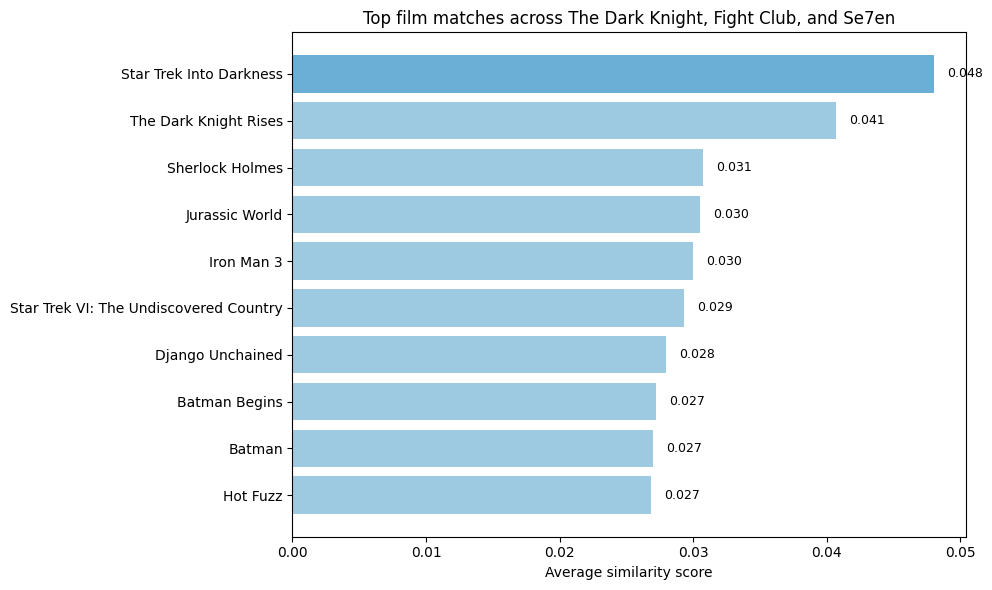
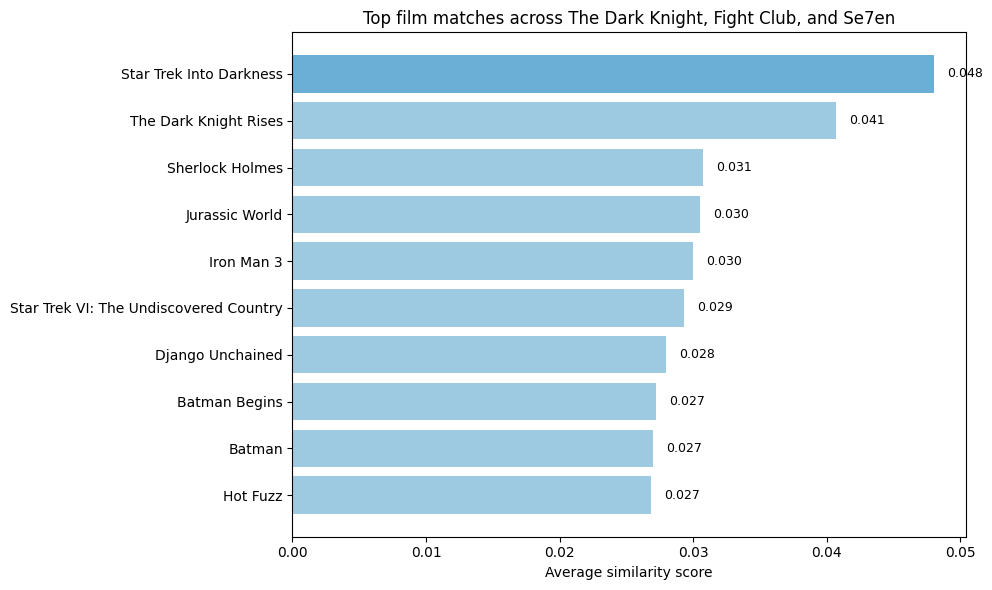

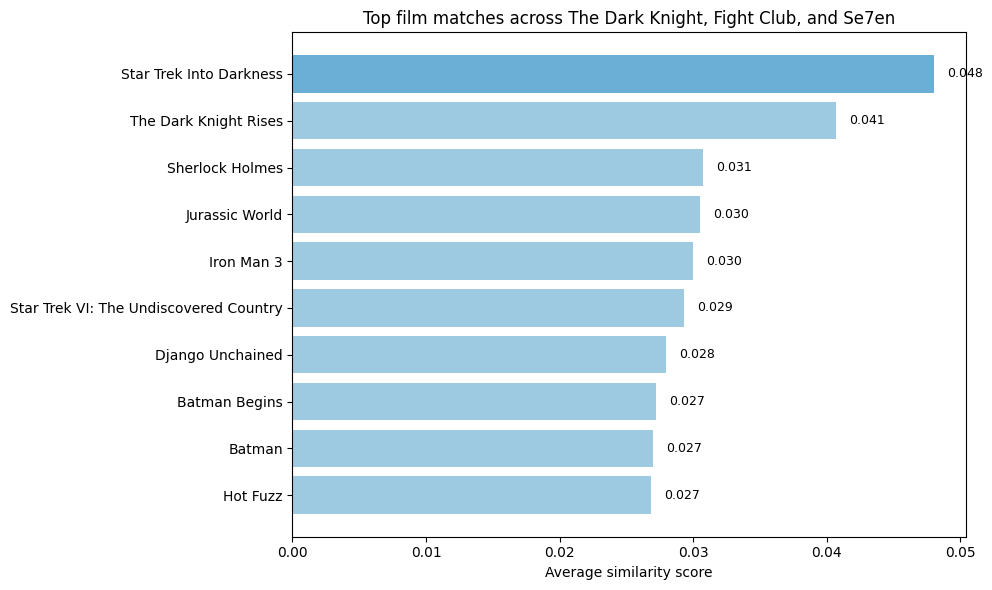

  → 1 image(s) downloaded and displayed above.

ASSISTANT REPLY:
Absolutely — I’d start with the strongest cross-over picks from the three films’ trope matches.

Here’s the chart of the best overall matches across The Dark Knight, Fight Club, and Se7en.

[Download the chart](sandbox:/tmp/chart.png)

Top picks:
- Star Trek Into Darkness — the best overall overlap, and it shows up for both The Dark Knight and Fight Club. It shares BatmanGambit-style strategic plotting, high-stakes moral conflict, and that “everything is escalating fast” intensity. The Dark Knight match is especially strong because of its chaotic, adversarial-cat-and-mouse energy. 
- The Dark Knight Rises — very strongly aligned with The Dark Knight itself, with a big pile of shared Batman-world tropes and an even more brooding, high-pressure tone. If you want more of the same grim superhero seriousness, this is the clearest continuation. 
- Sherlock Holmes — fits the clever, tactical, mentally sparring side of The Dark K

In [26]:
# Example E: Similarity analysis with code_interpreter

reply_e, id_e = chat(
    "I'm a huge fan of The Dark Knight, Fight Club, and Se7en. "
    "All three have that dark, intense, psychological edge. "
    "What movies should I watch next that match that vibe? "
    "Can you show me a chart of the best matches?",
    verbose=True,
)

print("\nASSISTANT REPLY:")
print(reply_e)